<a href="https://colab.research.google.com/github/satyamchaurasia-4444/-CNN-Project-Cat-Vs-Dog-Image-Classification-Project-/blob/main/CNN_dog_vs_cat_P1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CNN model

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, BatchNormalization,Flatten, Dropout
import matplotlib.pyplot as plt
import cv2

In [2]:
# load train dataset

training_dataset=keras.utils.image_dataset_from_directory(
    directory='/content/drive/MyDrive/PROJECTS/Dog vs Cat image classification/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)

Found 20000 files belonging to 2 classes.


In [3]:
validation_datasets=keras.utils.image_dataset_from_directory(
    directory='/content/drive/MyDrive/PROJECTS/Dog vs Cat image classification/test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)

Found 5000 files belonging to 2 classes.


In [4]:
# Normalize the pixel value from [0,255] to [0,1]

def process(image,label):
  image=tf.cast(image/255.,tf.float32)
  return image,label

In [5]:
train_ds=training_dataset.map(process)
validation_ds=validation_datasets.map(process)

In [6]:
# CNN model architecture

model=Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))

model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))

model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [8]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [9]:
history=model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3391s 5s/step - accuracy: 0.5644 - loss: 1.2339 - val_accuracy: 0.5658 - val_loss: 0.8230
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 77s 123ms/step - accuracy: 0.6572 - loss: 0.6161 - val_accuracy: 0.6892 - val_loss: 0.5873
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 109ms/step - accuracy: 0.7394 - loss: 0.5183 - val_accuracy: 0.7640 - val_loss: 0.5045
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 108ms/step - accuracy: 0.7824 - loss: 0.4409 - val_accuracy: 0.7732 - val_loss: 0.4968
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 107ms/step - accuracy: 0.8224 - loss: 0.3803 - val_accuracy: 0.7822 - val_loss: 0.4684
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 106ms/step - accuracy: 0.8539 - loss: 0.3200 - val_accuracy: 0.7870 - val_loss: 0.5090
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 92s 122ms/step - accuracy: 0.8845 - loss: 0.2548 - val_accuracy: 0.8128 - val_loss: 0.4228
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 108ms/step - accuracy: 0.9098 - loss: 0.

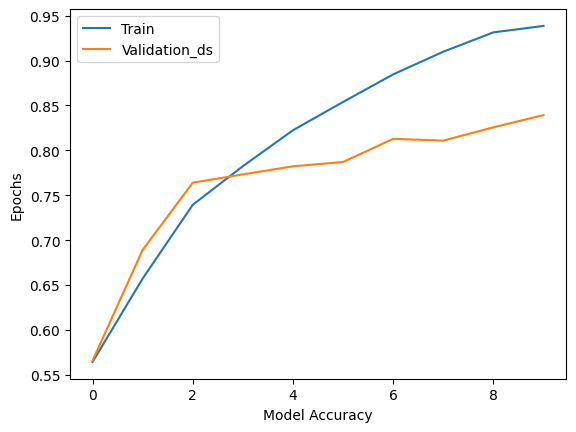

In [10]:
# loss and accuracy plots

plt.plot(figsize=(4,4))
plt.plot(history.history['accuracy'],label='Train')
plt.plot(history.history['val_accuracy'],label='Validation_ds')
plt.xlabel('Model Accuracy')
plt.ylabel('Epochs')
plt.legend()
plt.show()

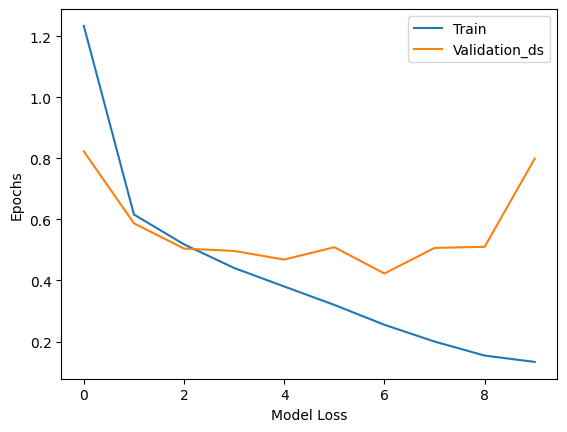

In [11]:
plt.plot(figsize=(4,4))
plt.plot(history.history['loss'],label='Train')
plt.plot(history.history['val_loss'],label='Validation_ds')
plt.xlabel('Model Loss')
plt.ylabel('Epochs')
plt.legend()
plt.show()

In [22]:
import os

image_path = '/content/drive/MyDrive/PROJECTS/Dog vs Cat image classification/train/cats/cat.1.jpg'

if not os.path.exists(image_path):
    print(f"Error: File not found at '{image_path}'. Please upload the image first.")
else:
    test_image = cv2.imread(image_path)
    if test_image is None:
        print("Error: Failed to read the image. The file might be corrupted.")
    else:
        test_image_resized = cv2.resize(test_image, (256, 256))
        test_input = test_image_resized.reshape((1, 256, 256, 3))
        test_input = test_input / 255.0
        prediction = model.predict(test_input)[0][0]
        print("Prediction:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Prediction: 1.2737458e-12


In [23]:
import numpy as np
np.where(prediction>0.5,'It is a Dog','It is a cat')

array('It is a cat', dtype='<U11')

In [24]:
if prediction>0.5:
  print('It is a Dog')
else:
  print('It is a cat')

It is a cat
